# GRF 보강 통합

단계별 보강: (1) LORO 공간 이전 검증 (2) 예측 구간·불확실성 (3) 로버스트 스케일 (4) SHAP 요인 설명 (5) 시설 효과 시나리오.

상위 노트북 `하남교산_시설물_효과_최적입지.ipynb`와 동일한 데이터·피처를 사용합니다.

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cwd = os.getcwd()
if 'grf_보강' in cwd:
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..', '..', '..'))
elif '77_gwrf' in cwd:
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
if not os.path.isdir(PROJECT_ROOT):
    PROJECT_ROOT = cwd

DATA_DIR = os.path.join(PROJECT_ROOT, 'data', '통합_데이터')
OUT_DIR = os.path.join(PROJECT_ROOT, 'notebooks', '77_gwrf', 'grf_보강')
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
print('PROJECT_ROOT:', PROJECT_ROOT)
print('OUT_DIR:', OUT_DIR)

PROJECT_ROOT: c:\Users\a0109\.jupyter\1최종_LH
OUT_DIR: c:\Users\a0109\.jupyter\1최종_LH\notebooks\77_gwrf\grf_보강


---
## 0. 데이터 로드 및 공통 설정

격자_최종통합, 하남교산 격자, 피처·타깃 정의 (상위 노트북과 동일).

In [ ]:
grid_path = os.path.join(DATA_DIR, '격자_최종통합.csv')
grid = pd.read_csv(grid_path, encoding='utf-8-sig', low_memory=False)

priority_path = os.path.join(DATA_DIR, '하남교산_설치우선순위_격자.csv')
if os.path.isfile(priority_path):
    priority = pd.read_csv(priority_path, encoding='utf-8-sig')
    hanam_gids = set(priority['gid'].dropna().astype(str))
else:
    hanam_gids = set(grid.loc[grid['gbn'].fillna('').astype(str).str.contains('하남', na=False), 'gid'].astype(str))

hanam_df = grid[grid['gid'].astype(str).isin(hanam_gids)].copy()
TARGET_COL = 'acc_count' if 'acc_count' in grid.columns else '격자내_미성년자_교통사고_건수'
FEATURE_CANDIDATES = [
    '도로_비율', '주거_비율', '상업_비율', '학교_비율', '녹지_비율',
    'velocity_mean', 'AADT_mean', 'FRIN_mean', 'TI_mean',
    '미성년자_유동', '노인_유동', '등하교_유동_평균'
]
FEATURE_COLS = [c for c in FEATURE_CANDIDATES if c in grid.columns]
train_df = grid[~grid['gid'].astype(str).isin(hanam_gids)].copy()
train_df = train_df.dropna(subset=[TARGET_COL])
for c in FEATURE_COLS:
    train_df[c] = pd.to_numeric(train_df[c], errors='coerce')
train_df = train_df.fillna(train_df.median(numeric_only=True))
print('학습 가능 격자:', len(train_df), '| 하남교산 격자:', len(hanam_df), '| 피처:', len(FEATURE_COLS))

학습 가능 격자: 98553 | 하남교산 격자: 770 | 피처: 12


---
## 1. LORO 공간 이전 검증

지역(`gbn`)별로 한 지역을 제외하고 학습한 뒤, 제외한 지역에서 검증하여 4시구→하남 이전 가능성을 점검합니다.

In [ ]:
# LORO: 지역별로 하나씩 빼고 학습 → 해당 지역에서 R2·RMSE
regions = train_df['gbn'].astype(str).dropna().unique()
regions = [r for r in regions if r and str(r) != 'nan']
loro_results = []
for holdout_region in regions:
    train_mask = train_df['gbn'].astype(str) != holdout_region
    X_tr = train_df.loc[train_mask, FEATURE_COLS]
    y_tr = np.log1p(train_df.loc[train_mask, TARGET_COL].values)
    X_te = train_df.loc[~train_mask, FEATURE_COLS]
    y_te = train_df.loc[~train_mask, TARGET_COL].values
    if len(X_te) < 10:
        continue
    rf_loro = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    rf_loro.fit(X_tr, y_tr)
    pred_log = rf_loro.predict(X_te)
    pred_count = np.expm1(pred_log)
    pred_count = np.maximum(0, pred_count)
    r2 = r2_score(y_te, pred_count)
    rmse = np.sqrt(mean_squared_error(y_te, pred_count))
    loro_results.append({
        'holdout_region': holdout_region,
        'n_train': int(train_mask.sum()),
        'n_test': int((~train_mask).sum()),
        'R2': round(r2, 4),
        'RMSE': round(rmse, 4),
   })
loro_df = pd.DataFrame(loro_results)
print('LORO 결과 (지역별 이전 성능):')
display(loro_df)
loro_df.to_csv(os.path.join(OUT_DIR, 'LORO_공간이전_결과.csv'), index=False, encoding='utf-8-sig')
print('저장:', os.path.join(OUT_DIR, 'LORO_공간이전_결과.csv'))

LORO 결과 (지역별 이전 성능):


,holdout_region,n_train,n_test,R2,RMSE
0,경기도 성남시,84040,14513,0.3159,0.7993
1,경기도 하남시,89689,8864,0.3833,0.4951
2,경기도 화성시,26954,71599,0.2149,0.3274
3,서울특별시 송파구,94976,3577,0.3153,1.3612


저장: c:\Users\a0109\.jupyter\1최종_LH\notebooks\77_gwrf\grf_보강\LORO_공간이전_결과.csv


---
## 2. 예측 구간·불확실성

RF 트리별 예측의 평균(점추정)과 표준편차(불확실성)를 구해, 격자별로 예측 구간과 "고위험·고불확실" 구분을 합니다.

In [ ]:
# 전체 학습으로 RF 적합 후 트리별 예측으로 구간 산출
X_tr = train_df[FEATURE_COLS]
y_tr = np.log1p(train_df[TARGET_COL].values)
rf_full = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_full.fit(X_tr, y_tr)

# 하남 격자 예측: 트리별 예측 → 평균, 표준편차
hanam_fill = hanam_df[FEATURE_COLS].copy()
for c in FEATURE_COLS:
    hanam_fill[c] = pd.to_numeric(hanam_fill[c], errors='coerce')
hanam_fill = hanam_fill.fillna(train_df[FEATURE_COLS].median())
tree_preds_log = np.array([tree.predict(hanam_fill) for tree in rf_full.estimators_])
pred_log_mean = tree_preds_log.mean(axis=0)
pred_log_std = tree_preds_log.std(axis=0)
pred_count_mean = np.expm1(pred_log_mean)
pred_count_mean = np.maximum(0, pred_count_mean)
# 구간: 로그 스케일에서 ±1.96*std 후 expm1
pred_count_lo = np.expm1(pred_log_mean - 1.96 * pred_log_std)
pred_count_hi = np.expm1(pred_log_mean + 1.96 * pred_log_std)
pred_count_lo = np.maximum(0, pred_count_lo)

hanam_df = hanam_df.copy()
hanam_df['GRF_위험지수_설치전'] = pred_count_mean
hanam_df['GRF_예측_하한'] = pred_count_lo
hanam_df['GRF_예측_상한'] = pred_count_hi
hanam_df['GRF_예측_std'] = pred_log_std  # 로그 스케일 표준편차 (불확실성 지표)
hanam_df['고위험_고불확실'] = ((hanam_df['GRF_위험지수_설치전'] >= hanam_df['GRF_위험지수_설치전'].quantile(0.75)) & 
                                (hanam_df['GRF_예측_std'] >= hanam_df['GRF_예측_std'].quantile(0.75))).astype(int)
print('예측 구간·불확실성 산출 완료. 고위험·고불확실 격자 수:', hanam_df['고위험_고불확실'].sum())
hanam_df[['gid', 'GRF_위험지수_설치전', 'GRF_예측_하한', 'GRF_예측_상한', 'GRF_예측_std', '고위험_고불확실']].head(10)

예측 구간·불확실성 산출 완료. 고위험·고불확실 격자 수: 181


,gid,GRF_위험지수_설치전,GRF_예측_하한,GRF_예측_상한,GRF_예측_std,고위험_고불확실
17103,다사720443,0.000161,0.000000,0.000473,0.000159,0
17104,다사720444,0.000121,0.000000,0.000406,0.000145,0
17227,다사721443,0.000161,0.000000,0.000473,0.000159,0
17228,다사721444,0.000196,0.000000,0.000782,0.000299,0
17229,다사721445,0.000173,0.000000,0.000582,0.000209,0
17230,다사721446,0.000156,0.000000,0.000472,0.000161,0
17231,다사721447,0.000226,0.000000,0.000593,0.000187,0
17232,다사721448,0.000377,0.000105,0.000650,0.000139,0
17233,다사721449,0.000231,0.000000,0.000600,0.000188,0
17349,다사722441,0.000161,0.000000,0.000473,0.000159,0


---
## 3. 로버스트 스케일 (퍼센타일·로버스트 Min-Max)

위험지수를 Min-Max 대신 (1) 순위 기반 0~1, (2) 1~99% 백분위로 잘라낸 로버스트 Min-Max로 산출합니다.

In [6]:
x = hanam_df['GRF_위험지수_설치전'].values
# (1) 퍼센타일 순위 기반 0~1
rank = pd.Series(x).rank(method='average', pct=True).values
hanam_df['GRF_위험점수_퍼센타일'] = rank
# (2) 로버스트 Min-Max: 1%~99% 구간을 0~1로 스케일
p1, p99 = np.nanpercentile(x, [1, 99])
if p99 > p1:
    robust = (np.clip(x, p1, p99) - p1) / (p99 - p1)
else:
    robust = np.zeros_like(x)
hanam_df['GRF_위험점수_로버스트'] = robust
# 기존 방식 Min-Max (참고)
xmin, xmax = x.min(), x.max()
minmax = (x - xmin) / (xmax - xmin) if xmax > xmin else np.zeros_like(x)
hanam_df['GRF_위험점수_MinMax'] = minmax
print('스케일 요약: 퍼센타일 min/max =', round(hanam_df['GRF_위험점수_퍼센타일'].min(), 4), round(hanam_df['GRF_위험점수_퍼센타일'].max(), 4))
print('로버스트 min/max =', round(hanam_df['GRF_위험점수_로버스트'].min(), 4), round(hanam_df['GRF_위험점수_로버스트'].max(), 4))
hanam_df[['gid', 'GRF_위험지수_설치전', 'GRF_위험점수_퍼센타일', 'GRF_위험점수_로버스트', 'GRF_위험점수_MinMax']].head(10)

스케일 요약: 퍼센타일 min/max = 0.0026 1.0
로버스트 min/max = 0.0 1.0


,gid,GRF_위험지수_설치전,GRF_위험점수_퍼센타일,GRF_위험점수_로버스트,GRF_위험점수_MinMax
17103,다사720443,0.000161,0.135714,0.000048,1.465356e-05
17104,다사720444,0.000121,0.007143,0.000000,2.298918e-07
17227,다사721443,0.000161,0.135714,0.000048,1.465356e-05
17228,다사721444,0.000196,0.237013,0.000091,2.722327e-05
17229,다사721445,0.000173,0.190260,0.000063,1.906182e-05
17230,다사721446,0.000156,0.086364,0.000042,1.270925e-05
17231,다사721447,0.000226,0.317532,0.000128,3.793606e-05
17232,다사721448,0.000377,0.377273,0.000314,9.232080e-05
17233,다사721449,0.000231,0.327922,0.000135,3.981755e-05
17349,다사722441,0.000161,0.135714,0.000048,1.465356e-05


---
## 4. SHAP 요인 설명

RF 변수 중요도와 (가능 시) SHAP으로 "왜 해당 격자가 고위험인지" 요인별 기여도를 요약합니다.

In [7]:
# 변수 중요도 (RF feature_importances_)
imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)
print('피처 중요도 (상위 10):')
display(imp.head(10))

# SHAP (선택): 설치되어 있으면 상위 N개 격자에 대해 요약
SHAP_AVAILABLE = False
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    pass
if SHAP_AVAILABLE:
    sample_idx = min(200, len(hanam_fill))
    X_shap = hanam_fill.iloc[:sample_idx]
    explainer = shap.TreeExplainer(rf_full, X_shap)
    shaps = explainer.shap_values(X_shap)
    if isinstance(shaps, list):
        shaps = shaps[0] if len(shaps) == 1 else np.array(shaps).mean(axis=0)
    mean_abs_shap = np.abs(shaps).mean(axis=0)
    shap_imp = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False)
    print('\\nSHAP 기여도 (mean |SHAP|, 상위 10):')
    display(shap_imp.head(10))
else:
    print('\\nSHAP 미설치: pip install shap 후 재실행 시 SHAP 기여도 산출 가능.')

피처 중요도 (상위 10):


,feature,importance
11,등하교_유동_평균,0.414229
6,AADT_mean,0.253030
5,velocity_mean,0.091557
9,미성년자_유동,0.073083
10,노인_유동,0.054661
8,TI_mean,0.047678
7,FRIN_mean,0.043041
0,도로_비율,0.009017
4,녹지_비율,0.005458
1,주거_비율,0.004719


\nSHAP 기여도 (mean |SHAP|, 상위 10):


,feature,mean_abs_shap
6,AADT_mean,0.032882
11,등하교_유동_평균,0.008188
5,velocity_mean,0.003961
9,미성년자_유동,0.003380
8,TI_mean,0.002392
7,FRIN_mean,0.001897
10,노인_유동,0.001829
0,도로_비율,0.000000
3,학교_비율,0.000000
2,상업_비율,0.000000


---
## 5. 시설 효과 시나리오

동일 감소율(15%) 뿐 아니라, (1) 감소율 차등(고위험 격자에 더 높은 감소율 가정), (2) 교통량·속도 시나리오별 예측 변화를 산출합니다.

In [8]:
# (1) 기본 감소율 15%
REDUCTION_RATE = 0.15
hanam_df['예상_사고감소량'] = hanam_df['GRF_위험지수_설치전'] * REDUCTION_RATE
hanam_df['GRF_위험지수_설치후'] = (hanam_df['GRF_위험지수_설치전'] - hanam_df['예상_사고감소량']).clip(lower=0)

# (2) 감소율 차등: 상위 25% 고위험 격자는 20%, 나머지 10%
q75 = hanam_df['GRF_위험지수_설치전'].quantile(0.75)
hanam_df['감소율_차등'] = np.where(hanam_df['GRF_위험지수_설치전'] >= q75, 0.20, 0.10)
hanam_df['예상_사고감소량_차등'] = hanam_df['GRF_위험지수_설치전'] * hanam_df['감소율_차등']

# (3) 시나리오: 속도 90%, AADT 110% 적용 후 재예측
X_sc = hanam_fill.copy()
if 'velocity_mean' in X_sc.columns:
    X_sc['velocity_mean'] = X_sc['velocity_mean'] * 0.90
if 'AADT_mean' in X_sc.columns:
    X_sc['AADT_mean'] = X_sc['AADT_mean'] * 1.10
pred_sc = np.expm1(rf_full.predict(X_sc))
pred_sc = np.maximum(0, pred_sc)
hanam_df['시나리오_속도90_AADT110_예측'] = pred_sc
hanam_df['시나리오_변화'] = pred_sc - hanam_df['GRF_위험지수_설치전']

print('기본 예상 사고감소량 합:', hanam_df['예상_사고감소량'].sum().round(4))
print('차등 감소 예상 합:', hanam_df['예상_사고감소량_차등'].sum().round(4))
print('시나리오(속도90%, AADT110%) 평균 변화:', hanam_df['시나리오_변화'].mean().round(6))

기본 예상 사고감소량 합: 7.2204
차등 감소 예상 합: 9.4779
시나리오(속도90%, AADT110%) 평균 변화: 0.016152


---
## 6. 결과 저장 및 요약 시각화

보강 결과 CSV 저장, LORO·불확실성 요약 플롯.

저장: c:\Users\a0109\.jupyter\1최종_LH\notebooks\77_gwrf\grf_보강


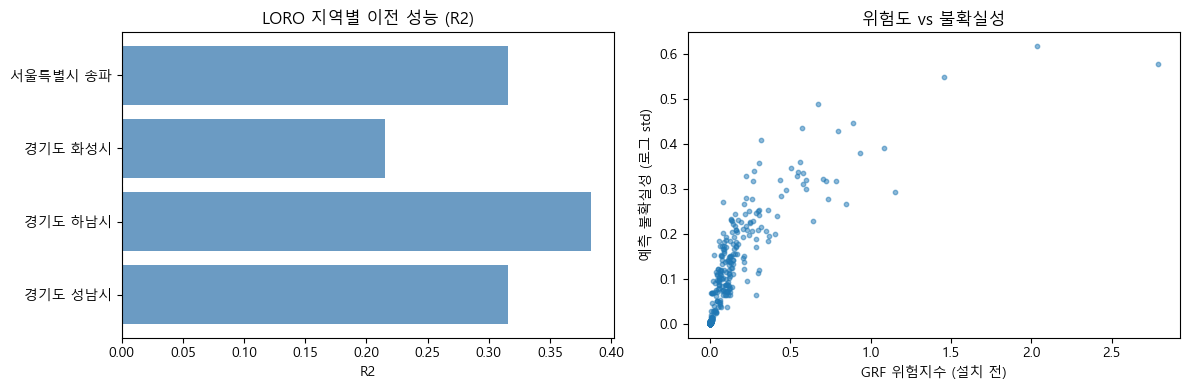

저장: GRF_보강_LORO_불확실성.png


In [9]:
os.makedirs(OUT_DIR, exist_ok=True)
hanam_df.to_csv(os.path.join(OUT_DIR, '하남교산_GRF_보강_결과.csv'), index=False, encoding='utf-8-sig')
if 'imp' in dir():
    imp.to_csv(os.path.join(OUT_DIR, 'GRF_피처_중요도.csv'), index=False, encoding='utf-8-sig')
print('저장:', OUT_DIR)

# LORO R2 막대, 예측 구간 요약
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(loro_df) > 0:
    axes[0].barh(loro_df['holdout_region'].astype(str).str[:8], loro_df['R2'], color='steelblue', alpha=0.8)
    axes[0].set_xlabel('R2')
    axes[0].set_title('LORO 지역별 이전 성능 (R2)')
    axes[0].axvline(x=0, color='gray', linestyle='--')
hanam_df.plot.scatter(x='GRF_위험지수_설치전', y='GRF_예측_std', alpha=0.5, s=10, ax=axes[1])
axes[1].set_xlabel('GRF 위험지수 (설치 전)')
axes[1].set_ylabel('예측 불확실성 (로그 std)')
axes[1].set_title('위험도 vs 불확실성')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_LORO_불확실성.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_LORO_불확실성.png')

---
## 7. 추가 시각화

스케일 비교, 예측 구간, 예상 사고감소량, 시나리오 변화, 고위험·고불확실 비율, 피처 중요도 등.

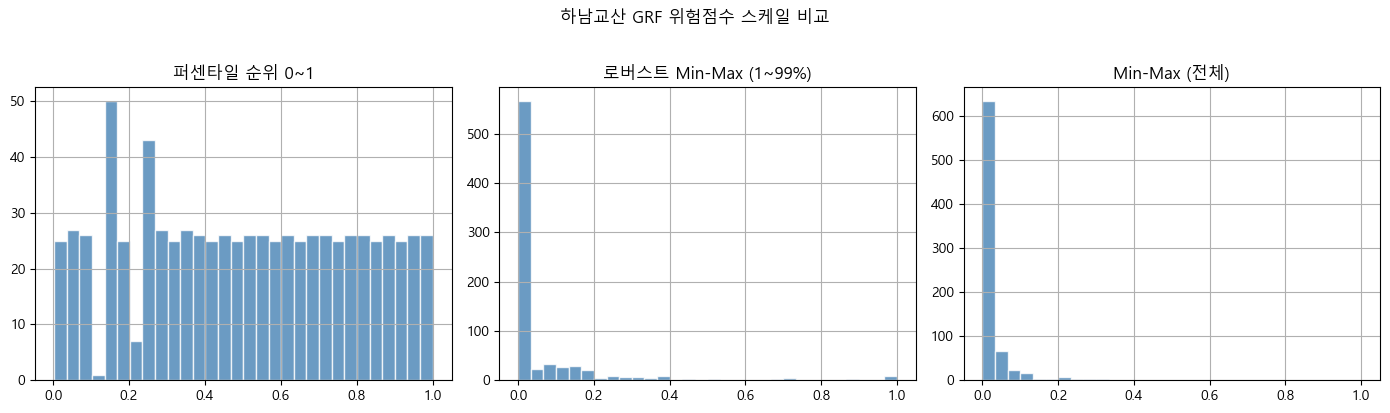

저장: GRF_보강_스케일_비교.png


In [10]:
# 7-1. 스케일 비교 (퍼센타일 vs 로버스트 vs MinMax)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
    ['GRF_위험점수_퍼센타일', 'GRF_위험점수_로버스트', 'GRF_위험점수_MinMax'],
    ['퍼센타일 순위 0~1', '로버스트 Min-Max (1~99%)', 'Min-Max (전체)']):
    hanam_df[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('')
plt.suptitle('하남교산 GRF 위험점수 스케일 비교', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_스케일_비교.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_스케일_비교.png')

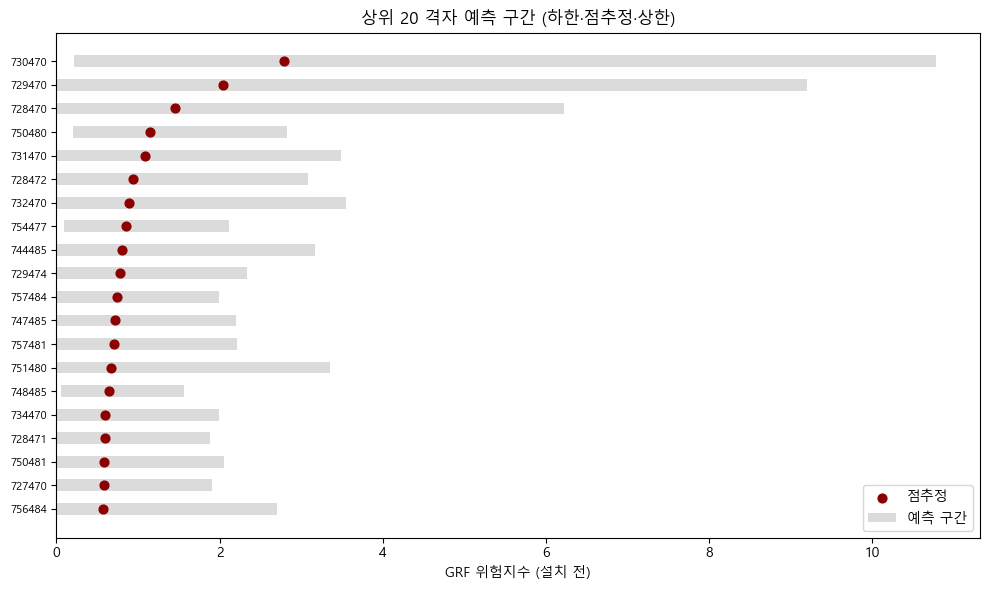

저장: GRF_보강_예측구간_상위20.png


In [11]:
# 7-2. 예측 구간 (상위 20 격자: 하한·점추정·상한)
top20 = hanam_df.nlargest(20, 'GRF_위험지수_설치전')[['gid', 'GRF_예측_하한', 'GRF_위험지수_설치전', 'GRF_예측_상한']].copy()
top20 = top20.sort_values('GRF_위험지수_설치전', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(top20))
ax.barh(x, top20['GRF_예측_상한'] - top20['GRF_예측_하한'], left=top20['GRF_예측_하한'], height=0.5, color='lightgray', alpha=0.8, label='예측 구간')
ax.scatter(top20['GRF_위험지수_설치전'].values, x, color='darkred', s=40, zorder=2, label='점추정')
ax.set_yticks(x)
ax.set_yticklabels(top20['gid'].astype(str).str[-6:], fontsize=8)
ax.set_xlabel('GRF 위험지수 (설치 전)')
ax.set_title('상위 20 격자 예측 구간 (하한·점추정·상한)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_예측구간_상위20.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_예측구간_상위20.png')

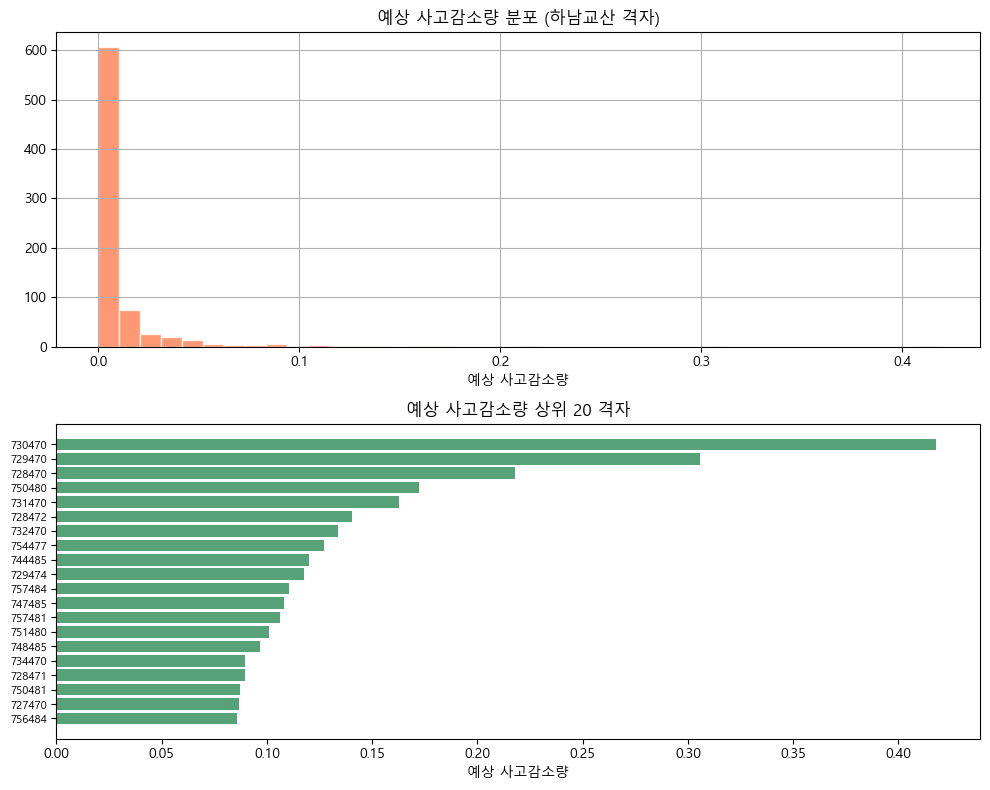

저장: GRF_보강_예상사고감소량.png


In [12]:
# 7-3. 예상 사고감소량 분포 + 상위 20 격자
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
hanam_df['예상_사고감소량'].hist(ax=axes[0], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title('예상 사고감소량 분포 (하남교산 격자)')
axes[0].set_xlabel('예상 사고감소량')

top_effect = hanam_df.nlargest(20, '예상_사고감소량')[['gid', '예상_사고감소량']].sort_values('예상_사고감소량', ascending=True)
axes[1].barh(range(len(top_effect)), top_effect['예상_사고감소량'], color='seagreen', alpha=0.8)
axes[1].set_yticks(range(len(top_effect)))
axes[1].set_yticklabels(top_effect['gid'].astype(str).str[-6:], fontsize=8)
axes[1].set_xlabel('예상 사고감소량')
axes[1].set_title('예상 사고감소량 상위 20 격자')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_예상사고감소량.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_예상사고감소량.png')

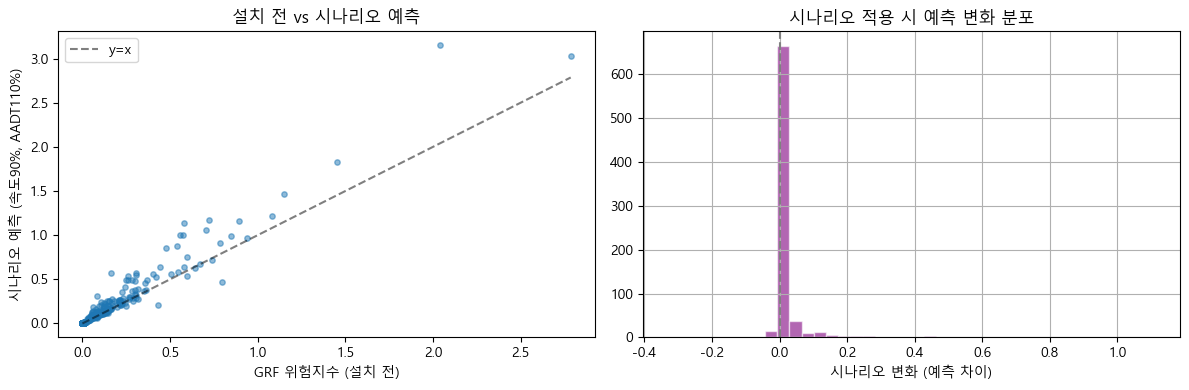

저장: GRF_보강_시나리오_변화.png


In [13]:
# 7-4. 시나리오(속도90%, AADT110%) 변화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hanam_df.plot.scatter(x='GRF_위험지수_설치전', y='시나리오_속도90_AADT110_예측', alpha=0.5, s=15, ax=axes[0])
axes[0].plot([0, hanam_df['GRF_위험지수_설치전'].max()], [0, hanam_df['GRF_위험지수_설치전'].max()], 'k--', alpha=0.5, label='y=x')
axes[0].set_xlabel('GRF 위험지수 (설치 전)')
axes[0].set_ylabel('시나리오 예측 (속도90%, AADT110%)')
axes[0].set_title('설치 전 vs 시나리오 예측')
axes[0].legend()

hanam_df['시나리오_변화'].hist(ax=axes[1], bins=40, color='purple', alpha=0.6, edgecolor='white')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel('시나리오 변화 (예측 차이)')
axes[1].set_title('시나리오 적용 시 예측 변화 분포')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_시나리오_변화.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_시나리오_변화.png')

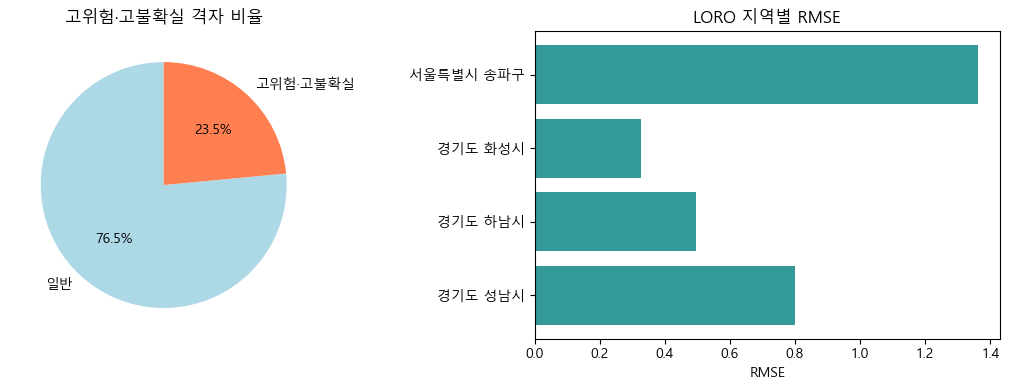

저장: GRF_보강_고위험비율_LORO_RMSE.png


In [14]:
# 7-5. 고위험·고불확실 격자 비율 + LORO RMSE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
v = hanam_df['고위험_고불확실'].value_counts().sort_index()
axes[0].pie(v.values, labels=['일반', '고위험·고불확실'], autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[0].set_title('고위험·고불확실 격자 비율')

if len(loro_df) > 0:
    axes[1].barh(loro_df['holdout_region'].astype(str).str[:10], loro_df['RMSE'], color='teal', alpha=0.8)
    axes[1].set_xlabel('RMSE')
    axes[1].set_title('LORO 지역별 RMSE')
else:
    axes[1].text(0.5, 0.5, 'LORO 결과 없음', ha='center', va='center', transform=axes[1].transAxes)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_고위험비율_LORO_RMSE.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_고위험비율_LORO_RMSE.png')

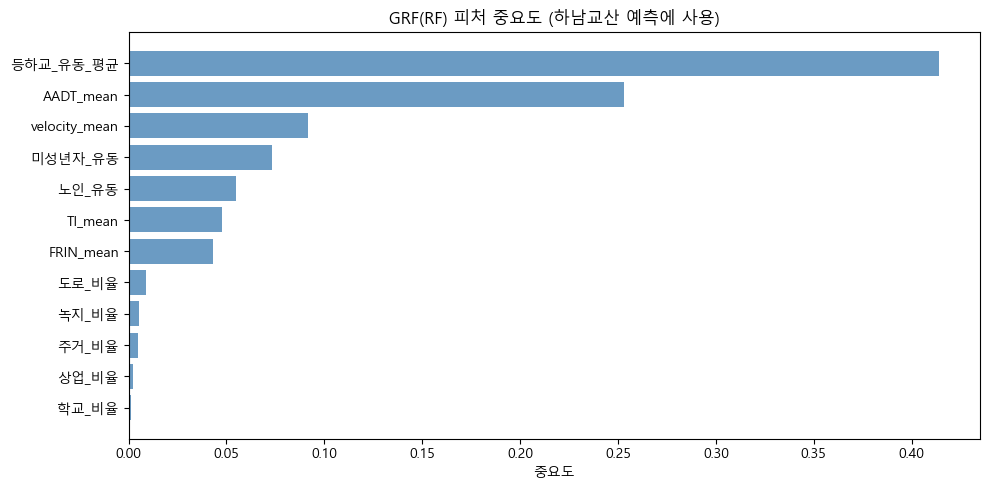

저장: GRF_보강_피처_중요도.png


In [15]:
# 7-6. 피처 중요도 (RF feature_importances_)
if 'imp' in dir() and imp is not None and len(imp) > 0:
    fig, ax = plt.subplots(figsize=(10, max(5, len(imp) * 0.3)))
    imp_sorted = imp.sort_values('importance', ascending=True)
    ax.barh(imp_sorted['feature'], imp_sorted['importance'], color='steelblue', alpha=0.8)
    ax.set_xlabel('중요도')
    ax.set_title('GRF(RF) 피처 중요도 (하남교산 예측에 사용)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_피처_중요도.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: GRF_보강_피처_중요도.png')
else:
    print('피처 중요도(imp) 없음: SHAP/변수 중요도 셀을 먼저 실행하세요.')

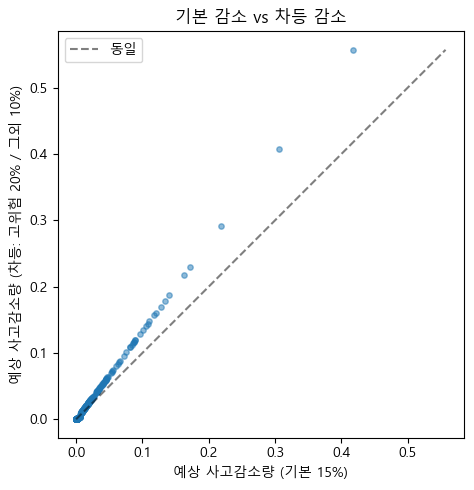

저장: GRF_보강_기본_vs_차등_감소.png


In [16]:
# 7-7. 기본 감소 vs 차등 감소 (예상 사고감소량)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(hanam_df['예상_사고감소량'], hanam_df['예상_사고감소량_차등'], alpha=0.5, s=15)
max_val = max(hanam_df['예상_사고감소량'].max(), hanam_df['예상_사고감소량_차등'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='동일')
ax.set_xlabel('예상 사고감소량 (기본 15%)')
ax.set_ylabel('예상 사고감소량 (차등: 고위험 20% / 그외 10%)')
ax.set_title('기본 감소 vs 차등 감소')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'GRF_보강_기본_vs_차등_감소.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: GRF_보강_기본_vs_차등_감소.png')